In [207]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA = Path(".")
RANDOM_STATE = 1090926

### A. Data presentation

Identify:

- what one row represents and what one biological mouse represents;
- the 77 numerical protein-expression measurements;
- MouseID and the experimental metadata;
- one possible prediction target.

Consider Genotype as a primary target: control versus trisomy. You may choose the eight-level class target instead, but explain why. Remember that class is constructed from genotype, behavior, and treatment.

In [167]:
data = pd.read_excel(DATA / "Data_Cortex_Nuclear.xls")
print(data.shape)

(1080, 82)


In [168]:
data

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,J3295_11,0.254860,0.463591,0.254860,2.092082,2.600035,0.211736,0.171262,2.483740,0.207317,...,0.183324,0.374088,0.318782,0.204660,0.328327,1.364823,Ts65Dn,Saline,S/C,t-SC-s
1076,J3295_12,0.272198,0.474163,0.251638,2.161390,2.801492,0.251274,0.182496,2.512737,0.216339,...,0.175674,0.375259,0.325639,0.200415,0.293435,1.364478,Ts65Dn,Saline,S/C,t-SC-s
1077,J3295_13,0.228700,0.395179,0.234118,1.733184,2.220852,0.220665,0.161435,1.989723,0.185164,...,0.158296,0.422121,0.321306,0.229193,0.355213,1.430825,Ts65Dn,Saline,S/C,t-SC-s
1078,J3295_14,0.221242,0.412894,0.243974,1.876347,2.384088,0.208897,0.173623,2.086028,0.192044,...,0.196296,0.397676,0.335936,0.251317,0.365353,1.404031,Ts65Dn,Saline,S/C,t-SC-s


**Answers**: 
- one row represents one sample, onr mouse is represented by 15 rows (3 different experiments x 5 dilations each)
- Protein-expression columns are all except MouseID, Genotype, Treatment, Behavior, class
- Mouse ID is beginning before _ in MouseID column (check below), experimental metadata are in columns Genotype, Treatment, Behavior, class, where class is an aggregate of genotype, behaviour and treatment.
- Genotype is obvious pred target, behaviour column is showing training in context fear conditioning (CFC), which could also alter protein level but this is rather human-intervention which isn't that useful to predict, as usually we would know if it happened or not. Same goes to Treatment, and consequtively - to the class column.

In [169]:
# Check mouseID consistency
data_with_mouse = data.copy()
data_with_mouse["Mouse"] = data_with_mouse["MouseID"].str.split("_", expand=True)[0]
data_with_mouse

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class,Mouse
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m,309
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m,309
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m,309
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m,309
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m,309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,J3295_11,0.254860,0.463591,0.254860,2.092082,2.600035,0.211736,0.171262,2.483740,0.207317,...,0.374088,0.318782,0.204660,0.328327,1.364823,Ts65Dn,Saline,S/C,t-SC-s,J3295
1076,J3295_12,0.272198,0.474163,0.251638,2.161390,2.801492,0.251274,0.182496,2.512737,0.216339,...,0.375259,0.325639,0.200415,0.293435,1.364478,Ts65Dn,Saline,S/C,t-SC-s,J3295
1077,J3295_13,0.228700,0.395179,0.234118,1.733184,2.220852,0.220665,0.161435,1.989723,0.185164,...,0.422121,0.321306,0.229193,0.355213,1.430825,Ts65Dn,Saline,S/C,t-SC-s,J3295
1078,J3295_14,0.221242,0.412894,0.243974,1.876347,2.384088,0.208897,0.173623,2.086028,0.192044,...,0.397676,0.335936,0.251317,0.365353,1.404031,Ts65Dn,Saline,S/C,t-SC-s,J3295


In [170]:
data_with_mouse["Mouse"].unique()

<StringArray>
[   '309',    '311',    '320',    '321',    '322',   '3415',   '3499',
   '3507',   '3520',   '3521',    '294',   '3412',   '3413',   '3419',
   '3420',   '3500',   '3503',    '362',    '364',    '365',   '3477',
   '3478',   '3479',   '3480',   '3484',   '3497', '50810A', '50810D',
 '50810F',   '3422',   '3423',   '3424',   '3481',   '3488',   '3489',
   '3490',   '3516',  'J2292',   '3414',   '3416',   '3417',   '3429',
   '3504',   '3505',   '3522',    '361',    '363',    '293',   '3411',
   '3418',   '3501',   '3502',   '3530',   '3534',   '3605',   '3606',
  '18899',   '3476',   '3483',   '3498', '50810B', '50810C', '50810E',
   '3421',   '3425',   '3426',   '3491',   '3513',   '3517',   '3525',
  'J1291',  'J3295']
Length: 72, dtype: str

In [171]:
# Check that really 15 replicates per mouse
counts = data_with_mouse["Mouse"].value_counts()
print(sum(counts != 15))

0


### B. EDA and tidy-data assessment

- load the Excel file and inspect dimensions, column names, and data types;
- inspect the distributions of Genotype, Treatment, Behavior, and class;
- check how many rows and how many unique mice belong to each group;
- visualize at least three biologically meaningful relationships.

Possible plots include:

- distributions of selected protein measurements by genotype;
- a PCA or two-dimensional projection colored by genotype, treatment, or behavior;
- protein-expression relationships or a correlation heatmap;
- the number of measurements per MouseID.

For every plot, state the biological question it addresses.

In [172]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MouseID          1080 non-null   str    
 1   DYRK1A_N         1077 non-null   float64
 2   ITSN1_N          1077 non-null   float64
 3   BDNF_N           1077 non-null   float64
 4   NR1_N            1077 non-null   float64
 5   NR2A_N           1077 non-null   float64
 6   pAKT_N           1077 non-null   float64
 7   pBRAF_N          1077 non-null   float64
 8   pCAMKII_N        1077 non-null   float64
 9   pCREB_N          1077 non-null   float64
 10  pELK_N           1077 non-null   float64
 11  pERK_N           1077 non-null   float64
 12  pJNK_N           1077 non-null   float64
 13  PKCA_N           1077 non-null   float64
 14  pMEK_N           1077 non-null   float64
 15  pNR1_N           1077 non-null   float64
 16  pNR2A_N          1077 non-null   float64
 17  pNR2B_N          1077 non

In [173]:
# how many rows in each group
metadata_columns_for_distribution = ["Genotype", "Behavior", "Treatment", "class"]
for metadata_col in metadata_columns_for_distribution:
    print(f"distribution for column {metadata_col}")
    print(data[metadata_col].value_counts())
    print()

distribution for column Genotype
Genotype
Control    570
Ts65Dn     510
Name: count, dtype: int64

distribution for column Behavior
Behavior
S/C    555
C/S    525
Name: count, dtype: int64

distribution for column Treatment
Treatment
Memantine    570
Saline       510
Name: count, dtype: int64

distribution for column class
class
c-CS-m    150
c-SC-m    150
c-CS-s    135
c-SC-s    135
t-CS-m    135
t-SC-m    135
t-SC-s    135
t-CS-s    105
Name: count, dtype: int64



In [174]:
# how many mice in each group
temp_df = data_with_mouse[metadata_columns_for_distribution + ["Mouse"]]
temp_df.drop_duplicates(inplace=True)
for metadata_col in metadata_columns_for_distribution:
    print(f"distribution for column {metadata_col}")
    print(temp_df[metadata_col].value_counts())
    print()

distribution for column Genotype
Genotype
Control    38
Ts65Dn     34
Name: count, dtype: int64

distribution for column Behavior
Behavior
S/C    37
C/S    35
Name: count, dtype: int64

distribution for column Treatment
Treatment
Memantine    38
Saline       34
Name: count, dtype: int64

distribution for column class
class
c-CS-m    10
c-SC-m    10
c-CS-s     9
c-SC-s     9
t-CS-m     9
t-SC-m     9
t-SC-s     9
t-CS-s     7
Name: count, dtype: int64



In [175]:
# biggest variance top 25 (more than one third) proteins
protein_cols = [
    col for col in data if col not in metadata_columns_for_distribution + ["MouseID"]
]
top_25_proteins = data[protein_cols].var().nlargest(25).index
df_top_var_proteins = data[top_25_proteins]
df_top_var_proteins

,pCAMKII_N,NR2A_N,ERK_N,pPKCG_N,pPKCAB_N,pELK_N,Bcatenin_N,ADARB1_N,NR1_N,pERK_N,...,ITSN1_N,DYRK1A_N,pCASP9_N,GSK3B_N,BRAF_N,pNR2A_N,AcetylH3K9_N,Ubiquitin_N,P70S6_N,pP70S6_N
0,2.373744,5.990152,3.685247,1.443091,2.308745,1.750936,3.037621,1.339070,2.816329,0.687906,...,0.747193,0.503644,1.603310,1.537227,0.416289,0.605673,0.170119,1.044979,0.842725,0.294170
1,2.292150,5.685038,3.485287,1.439460,2.043037,1.596377,2.921882,1.306323,2.789514,0.695006,...,0.689064,0.514617,1.671738,1.509249,0.400364,0.587559,0.171427,1.009883,0.847615,0.276431
2,2.283337,5.622059,3.571456,1.524364,2.017984,1.561316,2.944136,1.279600,2.687201,0.677348,...,0.730247,0.509183,1.663550,1.501244,0.399847,0.602449,0.185456,0.996848,0.856166,0.256648
3,2.152301,4.979503,2.970137,1.612382,2.132754,1.595086,2.500204,1.198765,2.466947,0.583277,...,0.617076,0.442107,1.484624,1.419710,0.385639,0.520293,0.159799,0.990225,0.760234,0.398534
4,2.134014,4.718679,2.896334,1.645807,2.013697,1.504230,2.456560,1.206995,2.365785,0.550960,...,0.617430,0.434940,1.534835,1.359876,0.367531,0.507990,0.164650,0.997775,0.768113,0.393447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,2.483740,2.600035,1.822906,2.630825,1.241958,1.057971,1.828208,0.737226,2.092082,0.265642,...,0.463591,0.254860,1.323554,0.993107,0.255744,0.510604,0.532987,1.261651,0.787900,0.527041
1076,2.512737,2.801492,1.879913,2.593227,1.361354,1.081150,1.883370,0.756047,2.161390,0.270378,...,0.474163,0.272198,1.275605,0.974891,0.252001,0.524381,0.546648,1.254872,0.763096,0.518377
1077,1.989723,2.220852,1.425262,2.628286,1.065022,0.884342,1.494208,0.764098,1.733184,0.255045,...,0.395179,0.228700,1.437534,0.818199,0.238042,0.442638,0.536899,1.242248,0.804896,0.460202
1078,2.086028,2.384088,1.558887,2.659706,1.115030,0.922595,1.571820,0.783185,1.876347,0.230649,...,0.412894,0.221242,1.498820,0.872820,0.256712,0.479522,0.538224,1.301071,0.784819,0.490496


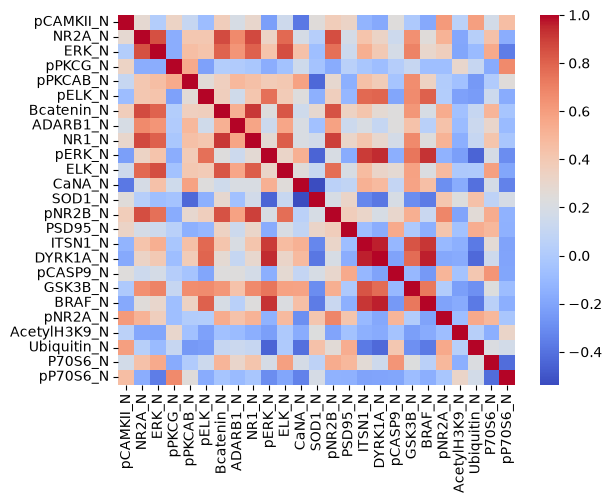

In [176]:
# correlation between proteins levels (for 25 with the biggest variance)
sns.heatmap(df_top_var_proteins.corr(), annot=False, cmap="coolwarm", fmt=".2f")
plt.show()

**Answer**: On the plot above we can see that there are highly correlated protein levels in the dataset. This allows to select subset of interesting proteins (include only one from correlated pair), as well as checking data validity. For example, we see high correlationg of ITSN1_N and DYRK1A_N, which are both on 21st chromosome and linked to brain activity/down syndrome, so it is expected for them to be correlated.

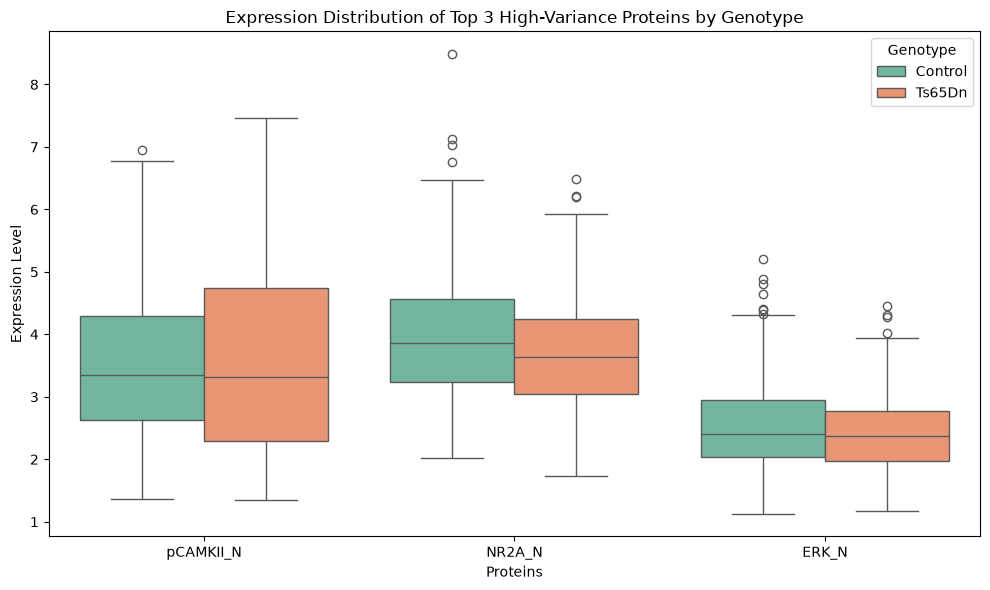

In [177]:
# Checking the distributions of top 3 protein (by variance) between genotypes
top_3_proteins = df_top_var_proteins.var().nlargest(3).index.tolist()
df_top_3_var = data[["Genotype"] + top_3_proteins]

df_long = df_top_3_var.melt(
    id_vars=["Genotype"],
    value_vars=top_3_proteins,
    var_name="Protein",
    value_name="Expression Value",
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_long, x="Protein", y="Expression Value", hue="Genotype", palette="Set2"
)

plt.title("Expression Distribution of Top 3 High-Variance Proteins by Genotype")
plt.xlabel("Proteins")
plt.ylabel("Expression Level")
plt.legend(title="Genotype")
plt.tight_layout()
plt.show()


**Answer**: The plot above allows to understand differences in protein expression between groups and potentially focus on the ones, distributionof which is visually more different between groups.

In [178]:
# Need to impute as the data has NAs and won't work for PCA
imputer = SimpleImputer(strategy="median")
proteins_imputed = pd.DataFrame(
    imputer.fit_transform(data[protein_cols]), columns=protein_cols
)
proteins_imputed.isna().sum().sum()

np.int64(0)

In [179]:
# PCA fitting for all proteins, because we only have 77
proteins = StandardScaler().fit_transform(data[protein_cols])

pca = PCA(n_components=2)
coords = pca.fit_transform(proteins_imputed)

pca_df = pd.DataFrame(
    {
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "Genotype": data["Genotype"].astype(str).values,
        "Behavior": data["Behavior"].astype(str).values,
        "Treatment": data["Treatment"].astype(str).values,
    }
)

print("Explained variance:", pca.explained_variance_ratio_.round(3))

Explained variance: [0.415 0.292]


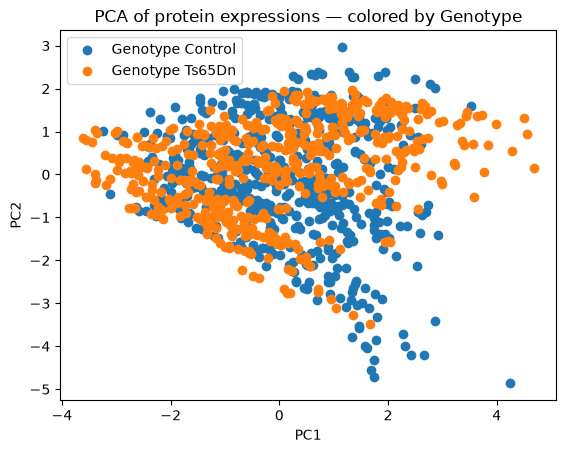

In [180]:
for batch, group in pca_df.groupby("Genotype"):
    plt.scatter(group["PC1"], group["PC2"], label=f"Genotype {batch}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of protein expressions — colored by Genotype")
plt.legend()
plt.show()

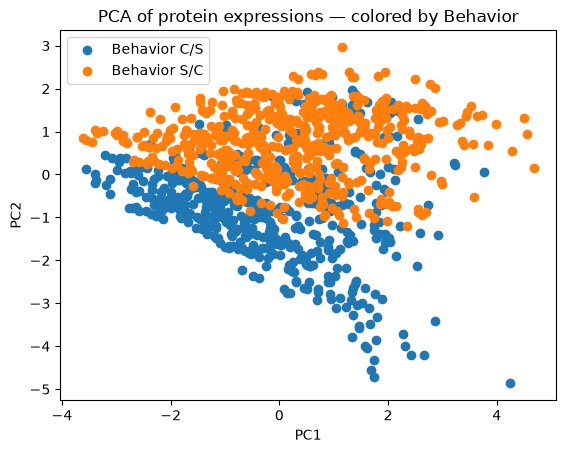

In [181]:
for batch, group in pca_df.groupby("Behavior"):
    plt.scatter(group["PC1"], group["PC2"], label=f"Behavior {batch}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of protein expressions — colored by Behavior")
plt.legend()
plt.show()

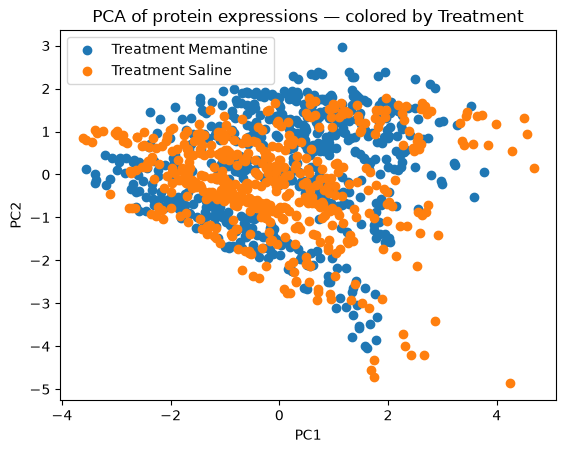

In [182]:
for batch, group in pca_df.groupby("Treatment"):
    plt.scatter(group["PC1"], group["PC2"], label=f"Treatment {batch}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of protein expressions — colored by Treatment")
plt.legend()
plt.show()

**Answer**: Some level of separation on PCA is only seen for behavior. We can also check genotype subset for saline treatment:

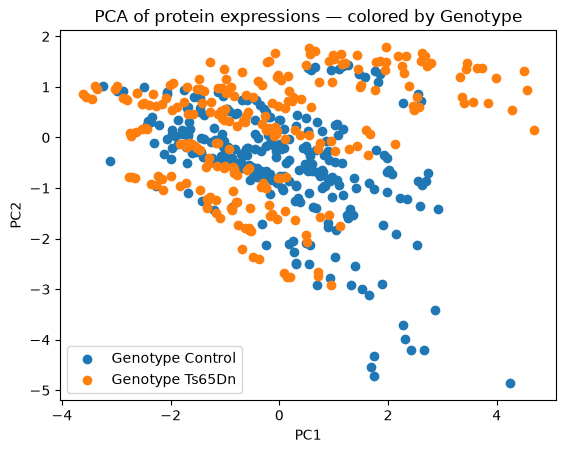

In [183]:
pca_df_saline = pca_df[pca_df["Treatment"] == "Saline"]
for batch, group in pca_df_saline.groupby("Genotype"):
    plt.scatter(group["PC1"], group["PC2"], label=f"Genotype {batch}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of protein expressions — colored by Genotype")
plt.legend()
plt.show()

**Answer**: the separation in this case is better, prooshowingving that it's best to consider saline treatment for easier training

### C. Diagnostics

Check:

- missingness in the protein measurements and metadata;
- duplicate rows and duplicate MouseID-measurement records;
- whether every mouse has the expected number of repeated measurements;
- unusual categories or inconsistent labels;
- non-finite, negative, or otherwise implausible expression values;
- highly correlated or redundant protein variables;
- whether any candidate predictor is a deterministic part of the target.

**Answer**: We already know that there are mmissing values in the data, but for further X/y creation I want to see if they are concentrated in specific samples / proteins / dilution levels. Starting with identifying which sample (-s) to keep for each mouse.

In [184]:
# check nans per sample
missing_by_column = data[protein_cols].isna().sum()
missing_by_row = data[protein_cols].isna().sum(axis=1)
print("Total missing protein expressions:", int(missing_by_column.sum()))
print("Features with at least one missing value:", int((missing_by_column > 0).sum()))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))

Total missing protein expressions: 1396
Features with at least one missing value: 49
Rows with at least one missing value: 528


In [ ]:
data_mouse_dilution_saline = data_with_mouse.copy()
data_mouse_dilution_saline = data_mouse_dilution_saline[
    data_mouse_dilution_saline["Treatment"] == "Saline"
]
data_mouse_dilution_saline["Dilution"] = (
    data_with_mouse["MouseID"].str.split("_", expand=True)[1].astype(int)
)
data_mouse_dilution_saline.head(15)

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class,Mouse,Dilution
300,3477_1,0.591618,0.814980,0.414980,2.706108,5.256264,0.260990,0.187249,4.163798,0.265894,...,0.154416,0.135307,NaN,1.399615,Control,Saline,C/S,c-CS-s,3477,1
301,3477_2,0.589807,0.840445,0.424325,2.803702,5.534373,0.269420,0.192834,4.284555,0.275985,...,0.163800,0.139480,NaN,1.410978,Control,Saline,C/S,c-CS-s,3477,2
302,3477_3,0.598902,0.886041,0.444760,2.918261,5.717712,0.290435,0.197162,4.497666,0.282288,...,0.154110,0.143156,NaN,1.332266,Control,Saline,C/S,c-CS-s,3477,3
303,3477_4,0.544844,0.726999,0.390846,2.521089,4.967323,0.275550,0.190962,4.576825,0.240209,...,0.177962,0.141927,NaN,1.394424,Control,Saline,C/S,c-CS-s,3477,4
304,3477_5,0.512785,0.730650,0.389176,2.514047,5.070519,0.271872,0.188625,4.548217,0.238390,...,0.184140,0.154982,NaN,1.366823,Control,Saline,C/S,c-CS-s,3477,5
305,3477_6,0.542164,0.780485,0.414548,2.672383,5.691898,0.283501,0.198699,4.806978,0.256062,...,0.174515,0.153216,NaN,1.320328,Control,Saline,C/S,c-CS-s,3477,6
306,3477_7,0.414109,0.606139,0.349671,2.107665,4.225133,0.281697,0.196208,4.127109,0.224168,...,0.190027,0.147236,NaN,1.387826,Control,Saline,C/S,c-CS-s,3477,7
307,3477_8,0.444973,0.627358,0.361981,2.217320,4.412498,0.296211,0.199278,4.275545,0.220272,...,0.187815,0.151207,NaN,1.357283,Control,Saline,C/S,c-CS-s,3477,8
308,3477_9,0.462778,0.683568,0.385111,2.369340,4.979651,0.301509,0.204172,4.481940,0.238257,...,0.185627,0.156498,NaN,1.261414,Control,Saline,C/S,c-CS-s,3477,9
309,3477_10,0.451309,0.647749,0.379476,2.057382,3.834764,0.294869,0.207749,3.866806,0.222827,...,0.201132,0.153238,NaN,1.392474,Control,Saline,C/S,c-CS-s,3477,10


**Answer**: From the look at the above (and what was said during the practical)I suspect that dilution levels for the first tissue sample are 1, 4, 7, etc. This is because (at least for visible proteins) the concentration seems to be more or less decreasing each row, which shouldn't have happened if the tissues were having consequtive ids.

In [ ]:
data_mouse_dilution_saline["True_dilution"] = (
    data_mouse_dilution_saline["Dilution"] - 1
) // 3 + 1
data_mouse_dilution_saline["True_dilution"].head(15)

300    1
301    1
302    1
303    2
304    2
305    2
306    3
307    3
308    3
309    4
310    4
311    4
312    5
313    5
314    5
Name: True_dilution, dtype: int64

In [187]:
total_nans_per_dilution = (
    data_mouse_dilution_saline.groupby("True_dilution")[protein_cols]
    .apply(lambda x: x.isna().sum().sum())
    .sort_values(ascending=False)
)

# with pd.option_context('display.max_rows', None):
print("Total NaNs per Dilution (Full List):")
print(total_nans_per_dilution)

Total NaNs per Dilution (Full List):
True_dilution
5    216
3     90
4     88
1     87
2     87
dtype: int64


**Answer**: as can be seen, the smallest number of NAs is for the 1st and second dilution levels. For the next steps the first one will be used.

In [188]:
data_mouse_first_dilution = data_mouse_dilution_saline.copy()
data_mouse_first_dilution = data_mouse_first_dilution[
    data_mouse_first_dilution["True_dilution"] == 1
]
data_mouse_first_dilution.shape

(102, 85)

In [189]:
total_nans_per_dilution = (
    data_mouse_first_dilution.groupby("Dilution")[protein_cols]
    .apply(lambda x: x.isna().sum().sum())
    .sort_values(ascending=False)
)

# with pd.option_context('display.max_rows', None):
print("Total NaNs per Dilution (Full List):")
print(total_nans_per_dilution)

Total NaNs per Dilution (Full List):
Dilution
1    29
2    29
3    29
dtype: int64


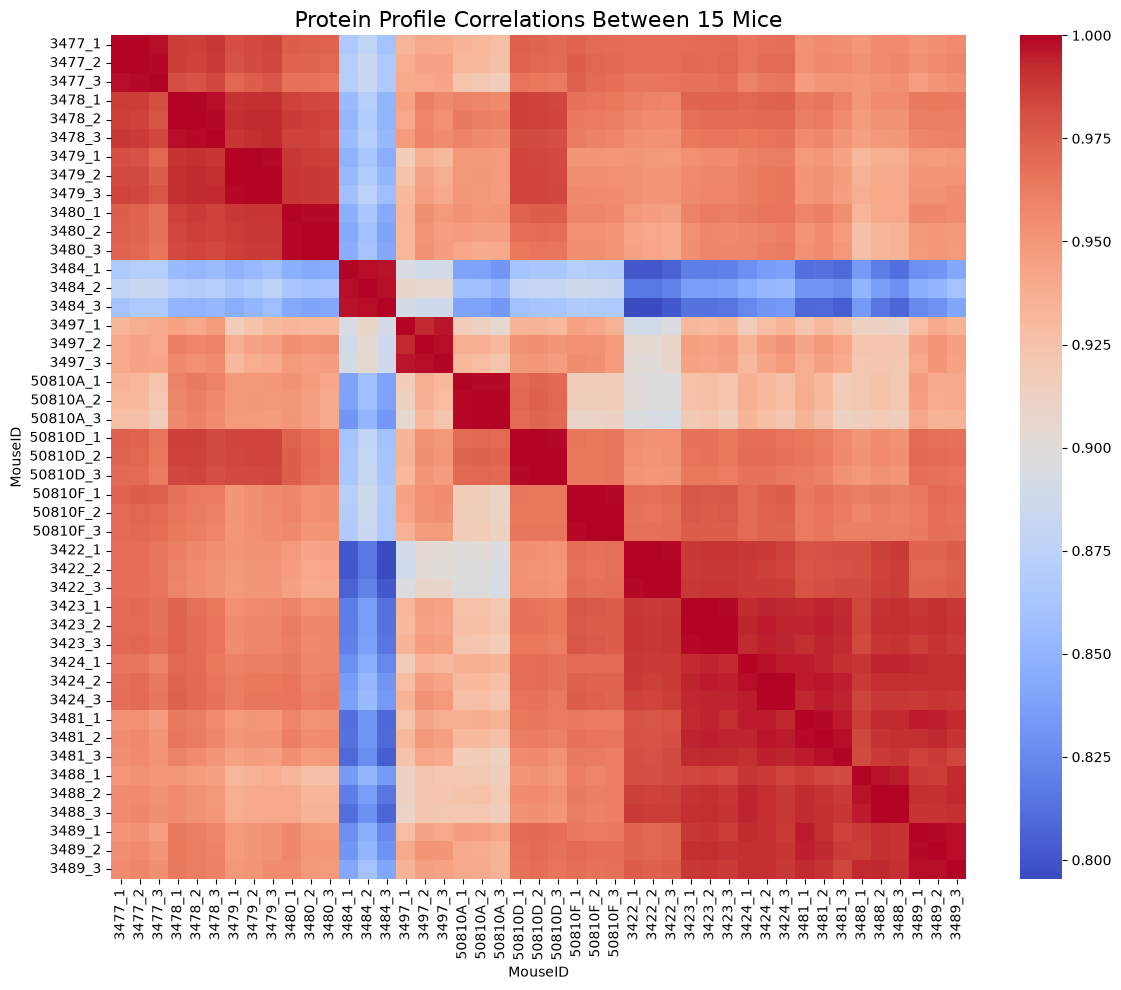

In [ ]:
# check if technical replicates are correlated
for_corr_first_dilution = data_mouse_first_dilution[protein_cols + ["MouseID"]]
df_with_index = for_corr_first_dilution.head(45).set_index("MouseID")

df_mice_transposed = df_with_index.T
mouse_corr_matrix = df_mice_transposed.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    mouse_corr_matrix,
    cmap="coolwarm",
    fmt=".2f",
    vmin=mouse_corr_matrix.min().min(),
    vmax=mouse_corr_matrix.max().max(),
)

plt.title("Protein Profile Correlations Between 15 Mice", fontsize=16)
plt.tight_layout()
plt.show()


**Answer**: The plot above shows that correlation between technical replicates is consistently high, and as they are having same amount of NAs, I decidedd to go with the 1st one.

In [ ]:
data_mouse_first = data_mouse_first_dilution[data_mouse_first_dilution["Dilution"] == 1]
df_rows_removed = data_mouse_first.dropna(subset=protein_cols)
features_without_missing = [
    column for column in protein_cols if data_mouse_first[column].notna().all()
]
X_features_removed = data_mouse_first[features_without_missing].copy()

print("Rows before removal:", len(data_mouse_first))
print("Rows after complete-row removal:", len(df_rows_removed))
print("Features before removal:", len(protein_cols))
print("Features after removal of any incomplete feature:", X_features_removed.shape[1])

Rows before removal: 34
Rows after complete-row removal: 20
Features before removal: 77
Features after removal of any incomplete feature: 69


**Answer**: it is much better to remove features (proteins). As this won't erase too much data, and is more statistically correct way to go (compared to imputation). Otherwise we are left with too few samples.

**Answers**
- Duplicated rows/MouseID checked before (A.)
- The expected number of samples also checked (A.). All good - 15 samples per mouse.
- Categories checked in part B. All good, no NAs there, no unexpected categories.

In [ ]:
(X_features_removed <= 0).sum().sum()

np.int64(0)

**Answer**: NAs have been cleaned, all other values are positive.

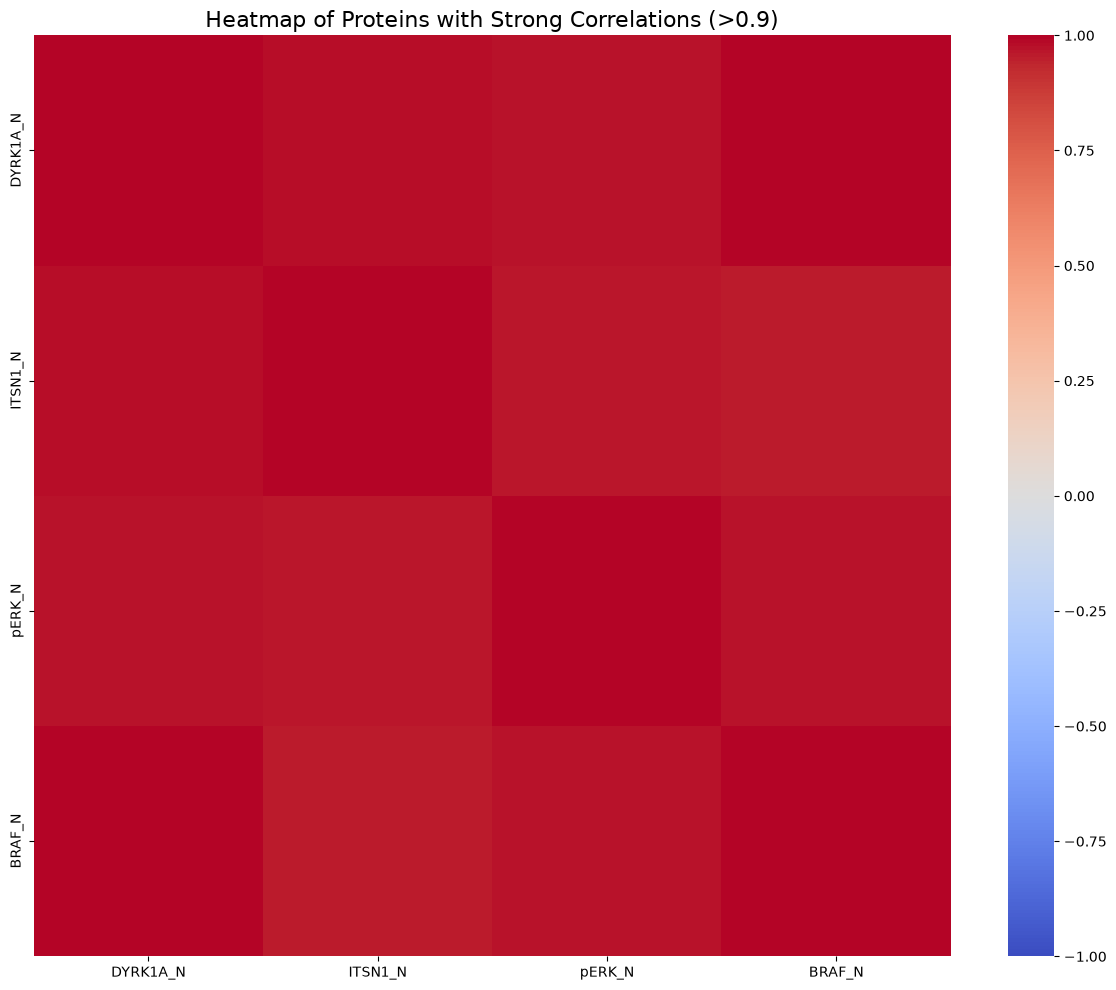

In [ ]:
correlations = data_mouse_first[X_features_removed.columns].corr()
matrix_no_diagonal = correlations.mask(correlations == 1.0)
high_corr_mask = (matrix_no_diagonal.abs() > 0.95).any(axis=1)

filtered_correlations = correlations.loc[high_corr_mask, high_corr_mask]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_correlations, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Heatmap of Proteins with Strong Correlations (>0.9)", fontsize=16)
plt.tight_layout()
plt.show()


In [194]:
filtered_correlations

,DYRK1A_N,ITSN1_N,pERK_N,BRAF_N
DYRK1A_N,1.000000,0.977723,0.976286,0.993979
ITSN1_N,0.977723,1.000000,0.966375,0.959812
pERK_N,0.976286,0.966375,1.000000,0.974915
BRAF_N,0.993979,0.959812,0.974915,1.000000


**Answer**: There is a set of 4 highly correlated proteins. 

*From Gemini*: DYRK1A and ITSN1 directly interact with and hyper-activate the Ras/MAPK pathway (which includes BRAF and pERK). Because they physically trigger each other in a tight molecular loop, an increase or decrease in one strongly drives an immediate, proportional change in the others.

**Answer**: Knowing this (and that biology behind it is valid, the correlatio is not random), we can remove 3 out of 4 to simplify our data further. I decided to leave only DYRK1A_N as it has highest correlation coeficients with others.

In [ ]:
protein_cols_filtered = [
    protein
    for protein in X_features_removed.columns
    if protein not in ["ITSN1_N", "BRAF_N", "pERK_N"]
]
data_filtered_all = data_mouse_first[protein_cols_filtered + ["Genotype"]]
data_filtered_all.shape

(34, 67)

**Answer**: No candidate predictor in this case (proteins) is deterministic part of the target (genotype). However, if we would try to predict class column and include treatment - we would get such situation.


### D. Preparation

Choose one supervised-learning problem and create:

    X
    y

Explain every variable that you exclude.

For a genotype-prediction question, start with the 77 protein measurements as candidate features. Exclude:

- MouseID and derived mouse_id, because the raw identifier identifies a measurement record and the derived identifier identifies the biological unit;
- the target column;
- class when Genotype is the target, because it contains genotype information;
- Treatment and Behavior unless you explicitly want a conditional prediction question and can justify their use.

Use the real missing values in the dataset to compare a defensible removal rule with an imputation rule. If you impute, fit the imputer on the training data only and apply it to the test data.

In [205]:
X = data_filtered_all[protein_cols_filtered].copy()
y = data_filtered_all["Genotype"].copy()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X remained features:", X.columns)

X shape: (34, 66)
y shape: (34,)
X remained features: Index(['DYRK1A_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N',
       'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pJNK_N', 'PKCA_N', 'pMEK_N',
       'pNR1_N', 'pNR2A_N', 'pNR2B_N', 'pPKCAB_N', 'pRSK_N', 'AKT_N',
       'CAMKII_N', 'CREB_N', 'ERK_N', 'GSK3B_N', 'JNK_N', 'MEK_N', 'TRKA_N',
       'RSK_N', 'APP_N', 'SOD1_N', 'MTOR_N', 'P38_N', 'pMTOR_N', 'DSCR1_N',
       'AMPKA_N', 'NR2B_N', 'pNUMB_N', 'RAPTOR_N', 'TIAM1_N', 'pP70S6_N',
       'NUMB_N', 'P70S6_N', 'pGSK3B_N', 'pPKCG_N', 'CDK5_N', 'S6_N',
       'ADARB1_N', 'AcetylH3K9_N', 'RRP1_N', 'BAX_N', 'ARC_N', 'ERBB4_N',
       'nNOS_N', 'Tau_N', 'GFAP_N', 'GluR3_N', 'GluR4_N', 'IL1B_N', 'P3525_N',
       'pCASP9_N', 'PSD95_N', 'SNCA_N', 'Ubiquitin_N', 'pGSK3B_Tyr216_N',
       'SHH_N', 'pS6_N', 'SYP_N', 'CaNA_N'],
      dtype='str')


**Answer**: In this case my goal would be to predict genotype based on protein expression levels. Only saline mice are included (as treatment modifies protein expression and on PCA made the samples rather undistinguishable). Only proteins with no NAs in their expression values remained and also highly correlated with DYRK1A_N proteins are excluded. Behavior is excluded, as I would like the model to generalize and work even when such info is not available - simply from the protein expression levels. Only one sample per mice is kept (due to high correlations of technical replicates and higher NA level at the next dilution stages)

### E. Split

Create an appropriate training/test split.

For generalization to unseen mice:

- derive and group by mouse_id;
- keep all 15 measurements from a mouse in the same partition;
- use a group-aware split such as GroupShuffleSplit or StratifiedGroupKFold when appropriate.

Explain:

- what population you want the model to generalize to;
- why a row-wise random split would give an over-optimistic estimate;
- what the independent biological unit is;
- whether stratification is needed and whether it is compatible with your grouping strategy.

**Answers**:
- I would like the model to generalize on untreated mice, independent of context fear conditioning. However, in paper it says that all mice are male, therefore the model won't generalize to females.
- For all rows of the original data row-wisse random split would result in one mice being present in both train and test sets and therefore final metric will be overpositive. As samples from one mice are very correlated, there is a high chance to overfit model for this 72 mice and not generalize for others. In my case, as I already selected one sample per mouse, this is unnecessary.
- One mouse is an independent biological unit.
- When splitting, stratification should be applied with regard to Genotype, so that test and train have similar proportions of these classes. Other grouppings are unnecessary as the data is already prefiltered.

In [210]:
row_indices = np.arange(len(data_filtered_all))

train_idx, test_idx = train_test_split(
    row_indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=data_filtered_all["Genotype"],
)
train_df = data_filtered_all.iloc[train_idx].copy()
test_df = data_filtered_all.iloc[test_idx].copy()

In [211]:
X_train = train_df[protein_cols_filtered].copy()
X_test = test_df[protein_cols_filtered].copy()

y_train = train_df["Genotype"].copy()
y_test = test_df["Genotype"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (25, 66)
X_test: (9, 66)
y_train: (25,)
y_test: (9,)


### F. Confounding and distribution structure

Investigate associations between the target and:

- treatment;
- behavior;
- genotype;
- the composite class;
- the number of measurements per mouse.

Use cross-tabulations and plots to ask:

- are treatment and behavior balanced across genotype?
- does the composite class encode the target directly?
- do some mice or experimental groups contribute different numbers of rows?
- could a model exploit experimental design structure instead of protein biology?

Identify at least one plausible source of confounding, target leakage, or distribution shift.

In [ ]:
treatment_tab = pd.crosstab(data["Genotype"], data["Treatment"], margins=True)
print("Treatment across Genotype counts:")
print(treatment_tab)
print()
print("Treatment across Genotype counts (mouse-level):")
print(treatment_tab // 15)

Treatment across Genotype counts:
Treatment  Memantine  Saline   All
Genotype                          
Control          300     270   570
Ts65Dn           270     240   510
All              570     510  1080

Treatment across Genotype counts (mouse-level):
Treatment  Memantine  Saline  All
Genotype                         
Control           20      18   38
Ts65Dn            18      16   34
All               38      34   72


In [ ]:
behavior_tab = pd.crosstab(data["Genotype"], data["Behavior"], margins=True)
print("Behavior across Genotype counts:")
print(behavior_tab)
print()
print("Behavior across Genotype counts (mouse-level):")
print(behavior_tab // 15)

Behavior across Genotype counts:
Behavior  C/S  S/C   All
Genotype                
Control   285  285   570
Ts65Dn    240  270   510
All       525  555  1080

Behavior across Genotype counts (mouse-level):
Behavior  C/S  S/C  All
Genotype               
Control    19   19   38
Ts65Dn     16   18   34
All        35   37   72


In [ ]:
# Check if class encodes genotype:
data_genotype_decoded = data.copy()
data_genotype_decoded["Genotype_d"] = data_genotype_decoded["class"].str.split(
    "-", expand=True
)[0]
data_genotype_decoded["Genotype_d"] = data_genotype_decoded["Genotype_d"].replace(
    {"c": "Control", "t": "Ts65Dn"}
)
print((data_genotype_decoded["Genotype_d"] != data_genotype_decoded["Genotype"]).sum())


0


**Answers**:
- Yes, the treatment and behaviour are well balanced, the largest difference between tabulated groups is 4 mice, which is ok. Also we know that they are well balanced from the paper.
- The class encodes genotype directly ("c" at the beginning for "Control", "t" for "Ts65Dn"). And this is also highlighted in the paper, that class encodes three other metadat columns, including Genotype.
- This was checked in the part A. All mice contribute the same amount of rows. But the amount of mice per different metadata subgroup varies a little and therefore the amount of rows for such subgroups also varies.
- As we took away treatment information, and no data provided to the model except proteins - I think model has nothing to exploit to "simplify" prediction.
- If class column would've been included, or multiple rows per mouse were included and split done randomly - that would've been data leakage. 

### G. Deliverable

Provide:

- X_train, X_test, y_train, y_test; **Answer**: provided in part E.
- a table documenting the role of each column; **Answer**: explanation in part A, but also table below.
- a missingness report and a justified removal or imputation decision; **Answer**: done in part C.
- plots if you want; **Answer**: some in different parts.
- a short Markdown interpretation describing: **Answer**: below
  - the ML question;
  - the biological unit;
  - the split strategy;
  - one potential source of bias, confounding, or leakage.


| Column | Explanation |
| :--- | :--- |
| **MouseID** | encodes individual mouse and sample from it in form Mouse_Sample |
| **Genotype** | Control or Ts65Dn for normal and trisomic mice correspondingly |
| **Treatment** | Memantine or Saline, showing if mice was given a treatment |
| **Behavior** | C/S or S/C depending on how mice was shocked (before or after exploring the cage in CFC protocol) |
| **class** | Encodes Genotype, Behavior and Treatment columns. 8 distinct classes |
| **other columns** | Protein expression levels obtained with RPPA |


**Answers**:
- *ML question*: classify genotype (in particular being able to identify trisomy Ts65Dn from protein expression levels, only for saline-treated mice).
- *Biological unit*: one individual mouse.
- *Split strategy*: stratified by genotype, no groupping applied due to prefiltering.
- *Source of bias*: discussed in part F.

## Optional advanced task

Compare two evaluation questions:

1. a random row-wise train/test split;
2. a mouse-grouped train/test split.

Are these evaluating the same kind of generalization? **Answer**: no, discussed in E part. 

As a second extension, compare predicting Genotype with predicting the composite class. Which question is biologically clearer, and which variables must be excluded to avoid target leakage?


**Answer**: the full class prediction overall would be more correct as all three included subclasses contribute to protein expression. However, biological usefulness of such model is unclear (ex: why would we need to predict if mouse was treated or not). Also there would be too few mice per class for training, if we would go with this approach. In any case, we should include only one of two class or other metadata columns.